### Introduction

The idea of this project is to update the gpt2 small model with modern practices. This is a learning exercise inspired by the book LLM from scratch from Sebastian Raschka. Upon finalizing the book and some of the extra material from the repository, I wanted to "reimplement" the model from the book using new architectural choices with a longer training dataset as a learning exercise for a model that is equivalent to GPT2_SMALL 124M.

In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from datasets import load_dataset
import random
from transformers import AutoTokenizer
import json
import numpy as np
import time
import math
from dataset import LMDataset
import matplotlib.pyplot as plt

/Users/lealal/Software/MachineLearning/gpt2-update/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Preparing the dataset

Sebastian uses a simple txt file for the pretraining phase, since the main goal of the book is to explain the concepts of LLMs. For this experiment, I wanted to use a bigger dataset and explore open source options. I decided to use RedPajama and sample some data for it. The paper indicates each document has around 1500 tokens: https://papers.nips.cc/paper_files/paper/2024/file/d34497330b1fd6530f7afd86d0df9f76-Paper-Datasets_and_Benchmarks_Track.pdf

I am planning on using 1B tokens for training, 25M for the validation set, and 25M for the test set. That should be enough for the pretraining phase and something my consumer laptop (M3 Pro MacBook) would be able to handle without spending weeks training the LLM. Since the dataset contains different quality types of documents, I will also be sampling from the "head" and "middle" quality buckets to avoid noisy docs. For 1.05B, that would equate to around 700k documents (1.05B tokens / 1500 tokens/perdoc = 700k docs). As a margin, 750k samples will be used.

In [2]:
TARGET_DOCS = 750_000
MIN_CHARS = 250

CONTEXT_LENGTH = 512

In [3]:
print('Collecting dataset...')

# https://huggingface.co/datasets/togethercomputer/RedPajama-Data-V2
dataset = load_dataset(
    'togethercomputer/RedPajama-Data-V2',
    'sample',
    split='train',
    streaming=True
)

texts = []
count = 0

for example in dataset:
    meta = example['meta']

    if isinstance(meta, str):
        meta = json.loads(meta)

    # Only use English examples
    if meta.get('language') != 'en':
        continue
        
    partition = meta.get('partition')

    if partition not in ['head_middle']:
        continue

    #  skip small docs
    if len(example['raw_content']) < MIN_CHARS:
        continue

    texts.append(example['raw_content'])
    count += 1

    if count >= TARGET_DOCS:
        break

print(f'Collected {len(texts):,} documents')

Collected 635,842 documents


In [4]:
# Validate some texts for sanity check
for i in range(3):
    print("---- DOC", i, "----")
    print(texts[i][:500])
    print()

---- DOC 0 ----
West Orange 973-243-0002
Florham Park 973-295-6226
Union 908-687-2000
Kintiroglou Pediatrics
Well Visits
Sick Visits
Lisa Pivawer, DO, FAAP
"Dr. Lisa" attended college at the University of Pennsylvania where she graduated in 1996. She then went to New York College of Osteopathic Medicine and received her Doctorate in May 2000. She completed her pediatrics residency at North Shore University Hospital - Long Island Jewish Medical Center in 2003. She has been certified by the American Board of Pedi

---- DOC 1 ----
Filters: Author is Manh Ha Hoang [Clear All Filters]
Martin, E., Browning, C., Farhang, A., Hoang, M. Ha, John, M., Ammann, M. J., Doyle, L. E., and Barry, L., “28 GHz 5G Radio over Fiber using UF-OFDM with Optical Heterodyning”, in International Topical Meeting on Microwave Photonics (MWP), Beijing, CN, 2017, pp. 1-4.
Hoang, M. Ha, Ahmed, Z., John, M., McEvoy, P., and Ammann, M. J., “Calibration for a Hybrid MIMO Near-field Imaging System to Mitigate Antennas E

In [3]:
tokenizer = AutoTokenizer.from_pretrained('gpt2')

In [6]:
all_tokens = []
max_len = tokenizer.model_max_length

for text in texts:
    tokens = tokenizer.encode(text)
    for i in range(0, len(tokens), max_len):
        chunk = tokens[i:i+max_len]
        all_tokens.extend(chunk)


print(f'Total tokens: {len(all_tokens):,}')

Token indices sequence length is longer than the specified maximum sequence length for this model (1412 > 1024). Running this sequence through the model will result in indexing errors


Total tokens: 774,100,543


In [7]:
# There are less tokens than the 1B expected, but this should still be enough
# as a learning exercise. If needed, the model will be trained in 2 epochs (expected to do 1)

train_size = int(len(all_tokens) * 0.9) # 696 M
val_size = int(len(all_tokens) * 0.05) # 39M - same for test

train_tokens = all_tokens[:train_size]
val_tokens = all_tokens[train_size:train_size+val_size]
test_tokens = all_tokens[train_size+val_size:]

In [8]:
np.array(train_tokens, dtype=np.uint16).tofile("train.bin")
np.array(val_tokens, dtype=np.uint16).tofile("val.bin")
np.array(test_tokens, dtype=np.uint16).tofile("test.bin")

In [4]:
class LMDataset(Dataset):
    def __init__(self, tokens_path, context_length, max_tokens=None):
        self.tokens = np.memmap(tokens_path, dtype=np.uint16, mode='r')
        self.context_length = context_length
        if max_tokens is None:
            self.num_sequences = (len(self.tokens) - 1) // context_length
        else:
            # limit to max_tokens
            self.num_sequences = min((len(self.tokens) - 1) // context_length,
                                     max_tokens // context_length)

    def __len__(self):
        return self.num_sequences

    def __getitem__(self, idx):
        start = idx * self.context_length

        input_tokens = self.tokens[start:start+self.context_length]
        label_tokens = self.tokens[start+1:start+self.context_length+1]

        input_tensor = torch.tensor(input_tokens, dtype=torch.long)
        target_tensor = torch.tensor(label_tokens, dtype=torch.long)

        return input_tensor, target_tensor

In [5]:
train_path = 'train.bin'
val_path = 'val.bin'
test_path = 'test.bin'

# After calculating how long it will take after some training, limiting to 500M
MAX_TRAINING_TOKENS = 500_000_000

train_dataset = LMDataset(train_path, CONTEXT_LENGTH, MAX_TRAINING_TOKENS)
val_dataset = LMDataset(val_path, CONTEXT_LENGTH)
test_dataset = LMDataset(test_path, CONTEXT_LENGTH)

In [6]:
# Test dataset
print(train_dataset.tokens[:10])

[15045 11942   860  4790    12 26660    12 34215   198 26953]


In [7]:
BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

In [8]:
# Test dataloader
example = next(iter(train_loader))
print(example)

[tensor([[15045, 11942,   860,  ...,    11,   347,  5488],
        [   11,  1395,    13,  ...,   326,   262,  1074],
        [  290, 27686,   389,  ...,   319,  3592,    13],
        ...,
        [  898,  7883,   290,  ...,   468,  2722,  3068],
        [  422,  1811, 12527,  ...,  8429,  4129,    13],
        [  198,   464,   734,  ..., 17514,  8171,    11]]), tensor([[11942,   860,  4790,  ...,   347,  5488,    11],
        [ 1395,    13,   406,  ...,   262,  1074,   290],
        [27686,   389,   564,  ...,  3592,    13,  2773],
        ...,
        [ 7883,   290,   703,  ...,  2722,  3068,   422],
        [ 1811, 12527,   329,  ...,  4129,    13,   198],
        [  464,   734, 48924,  ...,  8171,    11,   340]])]


## Prepare the model

This will reimplement GPT2 Small model with several changes:
- Remove Dropout. This is not used in modern architectures
- Use RoPE instead of Positional embeddings
- Use GroupedQueryAttention (GQA) instead of MultiHeadAttention(MHA)
- Use RMSNorm for layer normalization
- Use QK norm in attention block
- Use SiLU and additional linear layer in MLP
- Remove Dropout layers

In [9]:
class RMSNorm(nn.Module):
    def __init__(self, emb_dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.emb_dim = emb_dim
        self.weight = nn.Parameter(torch.ones(emb_dim)).float()

    def forward(self, x):
        means = x.pow(2).mean(dim=-1, keepdim=True)
        x_norm = x * torch.rsqrt(means+self.eps)
        return (x_norm * self.weight).to(dtype=x.dtype)

In [10]:
class MLP(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.fc1 = nn.Linear(cfg['emb_dim'], cfg['hidden_dim'], dtype=cfg['dtype'], bias=False)
        self.fc2 = nn.Linear(cfg['emb_dim'], cfg['hidden_dim'], dtype=cfg['dtype'], bias=False)
        self.fc3 = nn.Linear(cfg['hidden_dim'], cfg['emb_dim'], dtype=cfg['dtype'], bias=False)
        self.silu = nn.SiLU()

    def forward(self, x):
        x = self.silu(self.fc1(x)) * self.fc2(x)
        return self.fc3(x)

In [11]:
# RoFormer: https://arxiv.org/abs/2104.09864
def compute_rope_params(head_dim, theta, context_length):
    assert head_dim % 2 == 0, "head_dim must be even"

    # shape: (1, head_dim / 2)
    inv_freq = 1.0 / (theta ** (torch.arange(0, head_dim, 2).float() / head_dim)).unsqueeze(0)
    positions = torch.arange(context_length).unsqueeze(1) # shape: (context_length, 1)

    angles = positions * inv_freq # shape: (context_length, head_dim/2)

    angles = torch.cat([angles, angles], dim=1) # shape: (context_length, head_dim)

    cos = torch.cos(angles)
    sin = torch.sin(angles)

    return cos, sin

def compute_rope(x, cos, sin):
    batch, num_heads, seq_len, head_dim = x.shape
    assert head_dim % 2 == 0, 'head_dim must be even'

    x1 = x[..., :head_dim // 2] # (batch, num_heads, seq_len, head_dim/2)
    x2 = x[..., head_dim // 2:]

    cos = cos[:seq_len, :].unsqueeze(0).unsqueeze(0) # (1, 1, seq_len, head_dim)
    sin = sin[:seq_len, :].unsqueeze(0).unsqueeze(0)

    rotated = torch.cat((-x2, x1), dim=-1)
    x_rotated = (x*cos) + (rotated*sin)

    return x_rotated.to(dtype=x.dtype)

In [12]:
class GroupedQueryAttention(nn.Module):
    def __init__(self, emb_dim, context_length, num_heads, num_kv_groups, dtype):
        super().__init__()
        assert emb_dim % num_heads == 0, 'emb_dim must be divisible by num_heads'
        assert num_heads % num_kv_groups == 0, 'num_heads must be divisble by num_kv_groups'

        self.emb_dim = emb_dim
        self.num_heads = num_heads
        self.head_dim = emb_dim // num_heads
        self.num_kv_groups = num_kv_groups
        self.group_size = num_heads // num_kv_groups

        self.W_query = nn.Linear(emb_dim, emb_dim, bias=False, dtype=dtype)
        self.W_key = nn.Linear(emb_dim, num_kv_groups * self.head_dim, bias=False, dtype=dtype)
        self.W_value = nn.Linear(emb_dim, num_kv_groups * self.head_dim, bias=False, dtype=dtype)
        self.out_proj = nn.Linear(emb_dim, emb_dim, bias=False, dtype=dtype)

        self.q_norm = RMSNorm(self.head_dim, eps=1e-6)
        self.k_norm = RMSNorm(self.head_dim, eps=1e-6)

    def forward(self, x, mask, cos, sin):
        b, num_tokens, emb_dim = x.shape

        queries = self.W_query(x) # (b, num_tokens, emb_dim)
        keys = self.W_key(x) # (b, num_tokens, num_kv_groups * head_dim)
        values = self.W_value(x) # (b, num_tokens, num_kv_groups * head_dim)

        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)
        keys = keys.view(b, num_tokens, self.num_kv_groups, self.head_dim)
        values = values.view(b, num_tokens, self.num_kv_groups, self.head_dim)

        queries = queries.transpose(1,2) # (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1,2) # (b, num_kv_groups, num_tokens, head_dim)
        values = values.transpose(1,2) # (b, num_kv_groups, num_tokens, head_dim)

        queries = self.q_norm(queries)
        keys = self.k_norm(keys)

        keys = compute_rope(keys, cos, sin)
        queries = compute_rope(queries, cos, sin)

        # (b, num_heads, num_tokens, head_dim)
        keys = keys.repeat_interleave(self.group_size, dim=1) 
        values = values.repeat_interleave(self.group_size, dim=1)

        attn_scores = queries @ keys.transpose(2,3)

        attn_scores.masked_fill_(mask, -torch.inf)

        attn_weights = torch.softmax(attn_scores / self.head_dim ** 0.5, dim=-1)

        # (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1,2)

        context_vec = context_vec.reshape(b, num_tokens, emb_dim)
        context_vec = self.out_proj(context_vec)
        return context_vec

In [13]:
class Transformer(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.attn = GroupedQueryAttention(
            emb_dim=cfg['emb_dim'],
            context_length=cfg['context_length'],
            num_heads=cfg['n_heads'],
            num_kv_groups=cfg['n_kv_groups'],
            dtype=cfg['dtype']
        )

        self.mlp = MLP(cfg)
        self.norm1 = RMSNorm(emb_dim=cfg['emb_dim'])
        self.norm2 = RMSNorm(emb_dim=cfg['emb_dim'])

    def forward(self, x, mask, cos, sin):
        shortcut = x
        x = self.norm1(x)
        x = self.attn(x, mask, cos, sin)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.mlp(x)
        x = x + shortcut
        return x

In [14]:
class GPT2_Model(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg['vocab_size'], cfg['emb_dim'], dtype=cfg['dtype'])

        self.trf_blocks = nn.Sequential(
            *[Transformer(cfg) for _ in range(cfg['n_layers'])]
        )

        self.final_norm = RMSNorm(cfg['emb_dim'])
        self.out_head = nn.Linear(
            cfg['emb_dim'], cfg['vocab_size'], bias=False, dtype=cfg['dtype']
        )

        cos, sin = compute_rope_params(
            head_dim=cfg['emb_dim'] // cfg['n_heads'], 
            theta=10_000, # Same as original paper,
            context_length=cfg['context_length']
        )

        self.register_buffer('cos', cos, persistent=False)
        self.register_buffer('sin', sin, persistent=False)

        self.cfg = cfg

    def forward(self, x):
        x = self.tok_emb(x)

        num_tokens = x.shape[1]
        mask = torch.triu(
            torch.ones(num_tokens, num_tokens, device=x.device, dtype=torch.bool), diagonal=1
        )

        for trf in self.trf_blocks:
            x = trf(x, mask, self.cos, self.sin)

        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [15]:
MODEL_CONFIG = {
    'vocab_size': 50297,
    'context_length': CONTEXT_LENGTH,
    'n_layers': 10,
    'n_heads': 8,
    'n_kv_groups': 4,
    'emb_dim': 720,
    'hidden_dim': 1280,
    'dtype': torch.bfloat16
}

In [16]:
model = GPT2_Model(MODEL_CONFIG)

In [17]:
total_parameters = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_parameters:,}')

Total parameters: 115,644,600


In [18]:
device = torch.device('mps' if torch.mps.is_available() else 'cpu')
print(device)

mps


In [19]:
model.to(device)
model = torch.compile(model)

### Prepare training methods

In [20]:
def train(model, train_loader, val_loader, num_epochs, optimizer, eval_freq, eval_batches,
          message_freq, tokenizer, device, warmup_steps, initial_lr, min_lr):
    train_losses, val_losses = [], []
    global_step = -1

    peak_lr = optimizer.param_groups[0]['lr']
    total_training_steps = len(train_loader) * num_epochs
    lr_increment = (peak_lr - initial_lr) / warmup_steps

    model.train()
    start_time = time.time()

    optimizer.zero_grad()
    for epoch in range(num_epochs):
        for i, (input_batch, target_batch) in enumerate(train_loader):
            if global_step < warmup_steps:
                lr = initial_lr + global_step * lr_increment
            else:
                progress = ((global_step-warmup_steps) /
                            (total_training_steps-warmup_steps))
                lr = (
                    min_lr + (peak_lr - min_lr) * 0.5 * (1 + math.cos(math.pi * progress))
                )

            for param_group in optimizer.param_groups:
                param_group['lr'] = lr

            loss = calculate_batch_loss(model, input_batch, target_batch, device)
            loss = loss / GRAD_ACCUM_STEPS
            loss.backward()

            if (i + 1) % GRAD_ACCUM_STEPS == 0:
                optimizer.step()
                optimizer.zero_grad()

            global_step += 1

            if global_step % eval_freq == 0:
                model.eval()
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, eval_batches, device
                )

                train_losses.append(train_loss)
                val_losses.append(val_loss)

                end_time = time.time()

                freq_time_min = (end_time - start_time) / 60

                print(f'Step: {global_step:06d}/{total_training_steps:}. '
                      f'Train loss: {train_loss:.3f}, Val loss: {val_loss:.3f}. '
                      f'Elapsed time between eval: {freq_time_min:.2f}')

                start_time = time.time()

                model.train()

            if global_step % message_freq == 0:
                generate_sample(
                    model=model,
                    tokenizer=tokenizer,
                    device=device,
                    context='Dedication will always pay',
                    context_size=MODEL_CONFIG['context_length']
                )
                torch.save(model.state_dict(), 'model.pth')

    return train_losses, val_losses

In [21]:
def calculate_batch_loss(model, input_batch, target_batch, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch) # (batch, seq_len, vocab_size)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0,1), target_batch.flatten())
    return loss

In [22]:
def evaluate_model(model, train_loader, val_loader, eval_batches, device):
    model.eval()
    with torch.no_grad():
        train_loss = calculate_loader_loss(model, train_loader, eval_batches, device)
        val_loss = calculate_loader_loss(model, val_loader, eval_batches, device)

    model.train()
    return train_loss, val_loss

In [23]:
def calculate_loader_loss(model, loader, eval_batches, device):
    total_loss = 0
    for i, (input_batch, target_batch) in enumerate(loader):
        if i < eval_batches:
            loss = calculate_batch_loss(model, input_batch, target_batch, device)
            total_loss += loss.item()

        else:
            break

    total_loss /= eval_batches
    return total_loss

In [24]:
def generate_sample(model, tokenizer, device, context, context_size):
    model.eval()
    token_ids = tokenizer.encode(context, return_tensors='pt').to(device)
    with torch.no_grad():
        generated_ids = generate_text(
            model, token_ids, context_size, max_new_tokens=50
        )
    generated_text = tokenizer.decode(generated_ids[0])
    print(generated_text)
    model.train()

In [25]:
def generate_text(model, token_ids, context_size, max_new_tokens):
    for _ in range(max_new_tokens):
        # slice tokens if they exceed context_size
        token_ids_context = token_ids[:, -context_size:]

        with torch.no_grad():
            logits = model(token_ids_context)

        logits = logits[:, -1, :] # last token - ie: generated

        token_id = torch.argmax(logits, dim=-1, keepdim=True)

        token_ids = torch.cat((token_ids, token_id), dim=1) # (batch, token_ids+1)

    return token_ids

In [26]:
# Test model forward passes and generate function
generate_sample(
    model=model,
    tokenizer=tokenizer,
    device=device,
    context='Dedication will always pay',
    context_size=MODEL_CONFIG['context_length']
)

W0322 18:13:39.136000 10345 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


Dedication will always pay advisererr Clemson hopeless theat Pr June congenclusions Skirigersys logicalgomroth eye ellipt desolate bytes AlanRS Victoriarule bilingual Dana communion forecastWARD verteRecthn Directive CharmChristian Siberia economies atmospheric Artistptic elections tread Sabresrule touchdownistanominated assassblogspot desolate bytes


### Training

As expected, the model generated non sensical text as it is not trained. We will proceed with training.

For a consumer laptop, this is expected to take quite long, but I wanted to obtain a model that produces text with some sense. We will be training for a single epoch and doing evaluation every 10000 steps. Every 20000 steps, we will also generate a sample message to see the improvements.

In [27]:
torch.manual_seed(123)

num_epochs = 1
initial_lr = 3e-5
min_lr = 3e-5

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, fused=True)

# 5% warmup
warmup_steps = int((len(train_loader) * num_epochs) * 0.05)

# Improve training time
GRAD_ACCUM_STEPS = 2

start_training_time = time.time()
train_loss, val_loss = train(
    model=model, 
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=num_epochs,
    optimizer=optimizer,
    eval_freq=10000,
    eval_batches=10,
    message_freq=20000,
    tokenizer=tokenizer,
    device=device, 
    warmup_steps=warmup_steps,
    initial_lr=initial_lr,
    min_lr=min_lr
)
end_training_time = time.time()

Step: 000000/122070. Train loss: 10.994, Val loss: 11.000. Elapsed time between eval: 0.45
Dedication will always pay advisererr Clemson hopeless theat Pr June congenclusions Skirigersys logicalgomroth eye ellipt desolate bytes AlanRS Victoriarule bilingual Dana communion forecastWARD verteRecthn Directive CharmChristian Siberia economies atmospheric Artistptic elections tread Sabresrule touchdownistanominated assassblogspot desolate bytes
Step: 010000/122070. Train loss: 5.134, Val loss: 5.056. Elapsed time between eval: 103.92
Step: 020000/122070. Train loss: 4.641, Val loss: 4.544. Elapsed time between eval: 104.34
Dedication will always pay for the next few years.
The first time I was in the first place, I was in the first place, and I was in the first place. I was in the first place, and I was in the first place, and I was
Step: 030000/122070. Train loss: 4.467, Val loss: 4.341. Elapsed time between eval: 214.14
Step: 040000/122070. Train loss: 4.359, Val loss: 4.233. Elapsed time

In [28]:
elapsed_time_min = (end_training_time - start_training_time) / 60

print(f'Training completed in {elapsed_time_min:.2f} minutes')

Training completed in 1662.90 minutes


In [29]:
torch.save(model.state_dict(), 'model_last.pth')

### Evaluation

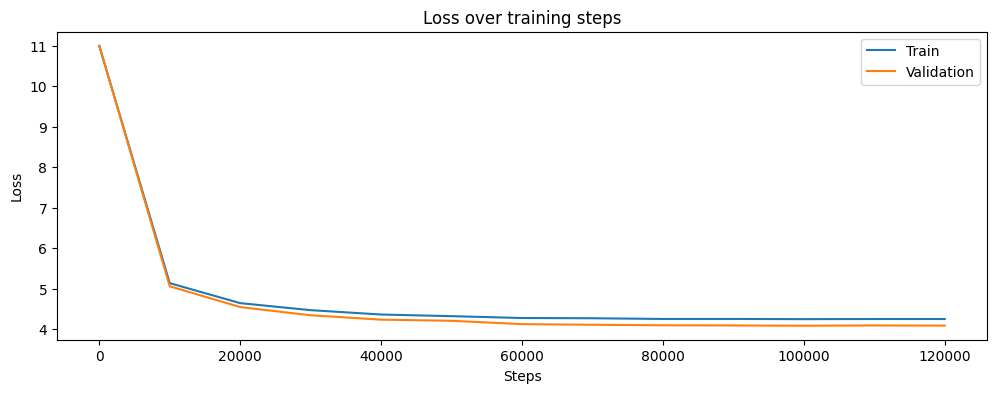

In [30]:
steps = np.arange(0, 120001, 10000)

plt.figure(figsize=(12,4))
plt.plot(steps, train_loss, label='Train')
plt.plot(steps, val_loss, label='Validation')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Loss over training steps')
plt.legend()
plt.show()

In [31]:
model.eval()

with torch.no_grad():
    test_loss = calculate_loader_loss(
        model=model,
        loader=test_loader,
        eval_batches=len(test_loader), 
        device=device
    )

print(f'Test loss: {test_loss:.3f}')

Test loss: 4.417


In [32]:
def calculate_perplexity(loss):
    return math.exp(loss)

perplexity = calculate_perplexity(test_loss)
print(f'Perplexity: {perplexity:.2f}')

Perplexity: 82.84


Training loss and validation loss are very similar during training, which is a good sign. It does not appear the model is overfitting. The generated text shows some local coherence, but also repetition. Given that the model is not training for long, it is somewhat expected. Will test the model with temperature to see if the generation improves

The test loss is also very similar to train and validation, so it seems to generalize well and training was stable. Probably training longer might help to find further improvements

In [33]:
def generate(model, token_ids, max_new_tokens, context_size, temperature=0.0, top_k=None):
    for _ in range(max_new_tokens):
        token_cond = token_ids[:, -context_size:]
        with torch.no_grad():
            logits = model(token_cond)
        logits = logits[:, -1, :]

        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        if temperature > 0.0:
            logits = logits / temperature

            logits = logits - logits.max(dim=-1, keepdim=True).values
            probs = torch.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1) 
        else:
            next_token = torch.argmax(logits, dim=-1, keepdim=True)

        token_ids = torch.cat((token_ids, next_token), dim=1)

    return token_ids

In [35]:
text1 = 'Dedication will always pay'
text2 = 'Large language models learn by'

text1_tokens = tokenizer.encode(text1, return_tensors='pt').to(device)
text2_tokens = tokenizer.encode(text2, return_tensors='pt').to(device)

generated_tokens_1 = generate(
    model=model,
    token_ids=text1_tokens,
    max_new_tokens=50,
    context_size=MODEL_CONFIG['context_length'],
    temperature=3.0, 
    top_k=5
)

generated_tokens_2 = generate(
    model=model,
    token_ids=text2_tokens,
    max_new_tokens=50,
    context_size=MODEL_CONFIG['context_length'],
    temperature=3.0, 
    top_k=20
)

generated_text_1 = tokenizer.decode(generated_tokens_1)
generated_text_2 = tokenizer.decode(generated_tokens_2)

print('Generated from example 1:\n', generated_text_1[0])
print()
print('Generated from example 2:\n', generated_text_2[0])

Generated from example 1:
 Dedication will always pay off. The results are very helpful. We are looking to improve the quality and quality assurance that our staff will be looking into. We have an extensive selection of products and solutions. I’ll also have a chance to discuss the benefits.


Generated from example 2:
 Large language models learn by creating a website that provides the content that will support HTML devices in place for users through a WordPress plugin with a plugin called FTP, a web interface and application form. In contrast we describe this information in the same way as using HTML or HTML using CSS


In this project, a transformer language model with 116M parameters was trained on approximately 500M tokens. The training and validation loss curves show steady improvement throughout training with no clear signs of overfitting, suggesting that the optimization process was stable and that the model generalized reasonably well to the validation data.

When evaluating the model through text generation, we observe that it is capable of producing grammatically correct sentences and coherent short passages. However, the model often falls into repetitive patterns after several tokens. This behavior is common in smaller language models and is likely due to limited model capacity and relatively modest training data.

The test set perplexity of approximately 82 is relatively high compared to modern large-scale models, but it is within the expected range for a model of this size trained on a limited dataset. This indicates that while the model has learned useful language structure, there is still significant uncertainty in its token predictions.

Despite these limitations, the model demonstrates promising results when using improved sampling strategies such as top-k sampling and higher temperature values, which increase diversity in generated text and reduce deterministic repetition.

Overall, the results show that even a moderately sized model trained on a relatively small corpus can learn meaningful linguistic patterns and generate coherent text, making this project a successful demonstration of the fundamental training process behind modern large language models.